In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Generating the data as directed by learning enviroment assignment's instructions.

In [3]:
# # import requests
# # import math
# # import re
# # import pandas as pd
# # from bs4 import BeautifulSoup

# headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:66.0) Gecko/20100101 Firefox/66.0"}
# url = 'https://www.vivino.com/'

# # Get Cache key to get country codes and type of wines
# response = requests.get(url, headers=headers)
# soup = BeautifulSoup(response.text, 'html.parser')
# script = soup.find('script', text = re.compile('var vivinoCacheKey'))
# # vivinoCacheKey = str(script).split('vivinoCacheKey = ')[-1].split(';')[0].replace("'",'').strip()

# # Get countries
# api_url = 'https://www.vivino.com/api/countries'
# payload = {
#     'cache_key':vivinoCacheKey}
# countryData = requests.get(api_url, headers=headers, params=payload).json()['countries']


# rows = []
# # Iterate through countries and wine types
# api_url = 'https://www.vivino.com/api/explore/explore'
# for country in countryData:
#     payload = {
#     "country_code": country['code'].upper(),
#     "currency_code":country['currency']['code'],
#     # 'grape_ids[]':'131',
#     "grape_filter":"varietal",
#     "min_rating":"1",
#     "order_by":"ratings_count",
#     "order":"desc",
#     "page": '1',
#     "price_range_max":"1000",
#     "price_range_min":"1"}
#     countryname = 'unknown'
#     try:
#         jsonData = requests.get(api_url, params=payload, headers=headers).json()
#         total_pages = math.ceil(jsonData['explore_vintage']['records_matched'] / 100)
#         #print('%s' %(country['code'].upper()))

#         for page in range(1,total_pages+1):
#             payload.update({'page':page})
#             jsonData = requests.get(api_url, params=payload, headers=headers).json()
#             for each in jsonData['explore_vintage']['records']:
#                 name = each['vintage']['name']
#                 country = each["vintage"]["wine"]["region"]["country"]["name"],
#                 region = each["vintage"]["wine"]["region"]["name"],
#                 rating =  each['vintage']['statistics']['ratings_average']
#                 rating_count =  each['vintage']['statistics']['ratings_count']
#                 price = each['price']['amount']
#                 countryname = each["vintage"]["wine"]["region"]["country"]["name"]
#                 row = {'name':name, 'country':country, 'region':region, 'rating':rating, 'rating_count':rating_count, 'price':price}
#                 rows.append(row)

#             print('Aquired page: %s - %s ' %(country, page))

#     except:
#         continue

#     df = pd.DataFrame(rows)
#     df = df.replace(r'\n',' ', regex=True)
#     df.to_csv("all_data2_" + countryname + ".csv", index=False)


In [4]:
alldata_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Final Assignment/all_data2_United States.csv")
alldata_df

,name,country,region,rating,rating_count,price
0,Meiomi Pinot Noir,"('United States',)","('California',)",4.1,183692,19.45
1,Catena Malbec 2024,"('Argentina',)","('Mendoza',)",4.0,166286,32.63
2,Veuve Clicquot Brut (Carte Jaune) Champagne,"('France',)","('Champagne',)",4.3,145394,48.00
3,The Prisoner Red Blend 2024,"('United States',)","('California',)",4.4,144286,39.99
4,Moët & Chandon Impérial Brut Champagne,"('France',)","('Champagne',)",4.1,139734,45.94
...,...,...,...,...,...,...
30667,Monte Degli Angeli Collezione del Barone Barol...,"('Italy',)","('Barolo',)",4.0,2920,29.68
30668,Josh Cellars Cabernet Sauvignon 2021,"('United States',)","('California',)",3.8,2916,22.79
30669,Famille Moutard Grande Cuvée Brut Champagne,"('France',)","('Champagne',)",3.9,2914,42.90
30670,Lagar Da Condesa O Fillo da Condesa Albariño 2024,"('Spain',)","('Rías Baixas',)",3.8,2911,18.33


Cleaning process: checking if the data has any null or nan (missing) values.


In [5]:
alldata_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30672 entries, 0 to 30671
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          30672 non-null  object 
 1   country       30672 non-null  object 
 2   region        30672 non-null  object 
 3   rating        30672 non-null  float64
 4   rating_count  30672 non-null  int64  
 5   price         30672 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 1.4+ MB


In [6]:
alldata_df.isna().sum()

,0
name,0
country,0
region,0
rating,0
rating_count,0
price,0


In [7]:
alldata_df.isnull().sum()

,0
name,0
country,0
region,0
rating,0
rating_count,0
price,0


Cleaning any unnecesary symbols.


In [8]:
def remove_characters(row):
  row = row[2:-3]
  return row

In [9]:
for col in ['country', 'region']:
   alldata_df[col] = alldata_df[col].apply(remove_characters)


In [10]:
alldata_df

,name,country,region,rating,rating_count,price
0,Meiomi Pinot Noir,United States,California,4.1,183692,19.45
1,Catena Malbec 2024,Argentina,Mendoza,4.0,166286,32.63
2,Veuve Clicquot Brut (Carte Jaune) Champagne,France,Champagne,4.3,145394,48.00
3,The Prisoner Red Blend 2024,United States,California,4.4,144286,39.99
4,Moët & Chandon Impérial Brut Champagne,France,Champagne,4.1,139734,45.94
...,...,...,...,...,...,...
30667,Monte Degli Angeli Collezione del Barone Barol...,Italy,Barolo,4.0,2920,29.68
30668,Josh Cellars Cabernet Sauvignon 2021,United States,California,3.8,2916,22.79
30669,Famille Moutard Grande Cuvée Brut Champagne,France,Champagne,3.9,2914,42.90
30670,Lagar Da Condesa O Fillo da Condesa Albariño 2024,Spain,Rías Baixas,3.8,2911,18.33


In [11]:
alldata_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30672 entries, 0 to 30671
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          30672 non-null  object 
 1   country       30672 non-null  object 
 2   region        30672 non-null  object 
 3   rating        30672 non-null  float64
 4   rating_count  30672 non-null  int64  
 5   price         30672 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 1.4+ MB


Working with Italian Wines only.

In [12]:
alldata_df = alldata_df[alldata_df['country'] == 'Italy']
alldata_df.shape

(11118, 6)

Finding out the best value for money on wines. Creating a new ''value for money'' column.

How to calculate the value for money? rating column divided by price column.

In [13]:
alldata_df['value_for_money'] = round(alldata_df['rating']/alldata_df['price'], 2)
alldata_df

/tmp/ipykernel_1421/3003427217.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  alldata_df['value_for_money'] = round(alldata_df['rating']/alldata_df['price'], 2)


,name,country,region,rating,rating_count,price,value_for_money
11,Piccini Memoro Rosso,Italy,Toscana,3.8,77347,18.33,0.21
51,La Marca Prosecco,Italy,Prosecco,3.8,34068,12.48,0.30
56,Masciarelli Montepulciano d'Abruzzo 2024,Italy,Montepulciano d'Abruzzo,3.7,31526,11.97,0.31
58,Mionetto Prestige Collection Brut Prosecco Tre...,Italy,Prosecco di Treviso,3.6,30634,10.98,0.33
61,Ferrari Trento Brut,Italy,Trento,3.8,28806,31.95,0.12
...,...,...,...,...,...,...,...
30663,Sella & Mosca Alghero Torbato Spumante Brut 2021,Italy,Alghero,3.7,2923,39.75,0.09
30664,Tavernello Rubicone Sangiovese 2024,Italy,Rubicone,3.3,2922,9.83,0.34
30665,Ruggeri Quartese Valdobbiadene Prosecco Superi...,Italy,Conegliano-Valdobbiadene Prosecco Superiore,4.0,2922,22.50,0.18
30666,Fantinel Tenuta Sant'Helena Pinot Grigio 2023,Italy,Collio,3.6,2920,27.34,0.13


maximum value for money for a bottle of wine

In [14]:
max_valueformoney = alldata_df['value_for_money'].max()
max_valueformoney

0.47

only one wine has the maximum ''value for money''

In [15]:
alldata_df[alldata_df['value_for_money']== max_valueformoney]

,name,country,region,rating,rating_count,price,value_for_money
755,Stella Rosa Moscato d'Asti Semi-Sweet,Italy,Piemonte,4.2,5613,8.97,0.47


checking if any wine has a 0.5 (or greater) value for money, we only get two results


In [27]:
alldata_df[alldata_df['value_for_money']>= 0.5]

,name,country,region,rating,rating_count,price,value_for_money


finally we get down to 0.4 and we got more to work with

In [17]:
alldata_df[alldata_df['value_for_money']>= 0.4]

,name,country,region,rating,rating_count,price,value_for_money
127,Roscato Rosso Dolce – Sweet Red,Italy,Provincia di Pavia,4.2,17332,9.97,0.42
755,Stella Rosa Moscato d'Asti Semi-Sweet,Italy,Piemonte,4.2,5613,8.97,0.47


Fiding out that 4.6 is the start of the highest amount of ratings that were given to different wines

In [18]:
alldata_df[alldata_df['rating']>= 4.6]

,name,country,region,rating,rating_count,price,value_for_money
170,Antinori Tignanello 2015,Italy,Toscana,4.6,14519,499.99,0.01
217,Gaja Sperss Barolo 2021,Italy,Barolo,4.6,12584,754.99,0.01
293,Quintarelli Giuseppe Amarone della Valpolicell...,Italy,Amarone della Valpolicella Classico,4.7,10729,573.85,0.01
1527,Gaja Costa Russi (Barbaresco) Langhe 2021,Italy,Barbaresco,4.6,3501,520.00,0.01


which wines have the highest rating and the highest amount of people rating it

In [19]:
# 183692
alldata_df[(alldata_df['rating']>= 4.6) & (alldata_df['rating_count']>= 10000)]

,name,country,region,rating,rating_count,price,value_for_money
170,Antinori Tignanello 2015,Italy,Toscana,4.6,14519,499.99,0.01
217,Gaja Sperss Barolo 2021,Italy,Barolo,4.6,12584,754.99,0.01
293,Quintarelli Giuseppe Amarone della Valpolicell...,Italy,Amarone della Valpolicella Classico,4.7,10729,573.85,0.01


Which wines (producers/regions) are most preferred by consumers?

By name of the wine


In [20]:
preferred_wines = alldata_df[(alldata_df['rating_count']>= 500)]
wines_preferred_bycustomers = preferred_wines.groupby('name').agg(
    average_rating = ('rating', 'mean'),
    total_ratings = ('rating_count', 'sum')
    ).sort_values(by = ['average_rating', 'total_ratings'], ascending = False)
wines_preferred_bycustomers.head(10)


,average_rating,total_ratings
name,,
Quintarelli Giuseppe Amarone della Valpolicella Classico 2018,4.7,10729
Antinori Tignanello 2015,4.6,14519
Gaja Sperss Barolo 2021,4.6,12584
Gaja Costa Russi (Barbaresco) Langhe 2021,4.6,3501
Dal Forno Romano Valpolicella Superiore Monte Lodoletta 2019,4.5,15631
Tenuta Ulisse Limited Edition 10 Vendemmie,4.5,14627
Bussola Amarone della Valpolicella Classico 2020,4.5,7956
Giacomo Conterno Barolo Cascina Francia 2021,4.5,7639
Gaja Gaia & Rey Langhe 2023,4.5,7353


by region

In [21]:
preferred_wines = alldata_df[(alldata_df['rating_count']>= 500)]
wines_preferred_bycustomers1 = preferred_wines.groupby('region').agg(
    average_rating = ('rating', 'mean'),
    total_ratings = ('rating_count', 'sum')
    ).sort_values(by = ['average_rating', 'total_ratings'], ascending = False).round(2)
wines_preferred_bycustomers1.head(10)

,average_rating,total_ratings
region,,
Amarone della Valpolicella Classico,4.40,3563868
Langhe,4.30,23283
Valdarno di Sopra,4.30,10762
Sant'Antimo,4.30,3168
Amarone della Valpolicella,4.30,3155
Barbaresco,4.25,26786
Primitivo di Manduria,4.25,7244
Brunello di Montalcino,4.23,105845
Provincia di Pavia,4.20,21364


In [22]:
preferred_wines = alldata_df[(alldata_df['rating_count']>= 500)]
wines_preferred_bycustomers2 = preferred_wines.groupby('region').agg(
    total_ratings = ('rating_count', 'sum')
    ).sort_values(by = ['total_ratings'], ascending = False).round(2)
wines_preferred_bycustomers2.head(10)

,total_ratings
region,
Moscato d'Asti,10533557
Barolo,3620520
Amarone della Valpolicella Classico,3563868
Conegliano-Valdobbiadene Prosecco Superiore,3558357
Collio,3498734
Alghero,3492985
Rubicone,3488868
Toscana,304495
Prosecco,186656


This plot contains the total number of wine ratings (y axis) and the names of the regions (x axis)

this one doesn't take into account which wine has the best rating

only the number of ratings

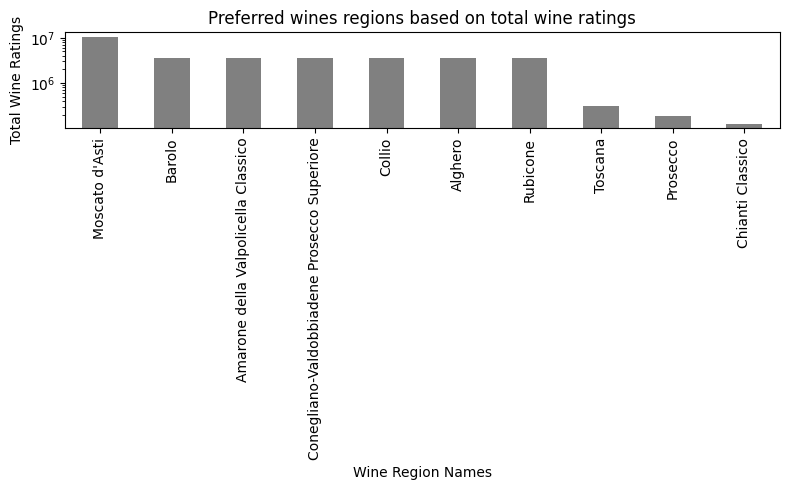

In [23]:
top10_2 = wines_preferred_bycustomers2.head(10)
plt.figure(figsize=(8, 5))
top10_2['total_ratings'].plot(kind= 'bar', color= 'grey')
plt.title('Preferred wines regions based on total wine ratings')
plt.xlabel('Wine Region Names')
plt.ylabel('Total Wine Ratings')
plt.xticks(rotation= 90)
plt.yscale('log')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/Final Assignment/plot2.png")
plt.show()

this plot contains the total number of ratings (y axis) of the best rated wine regions (x axis)

this one takes into account the best rated wines

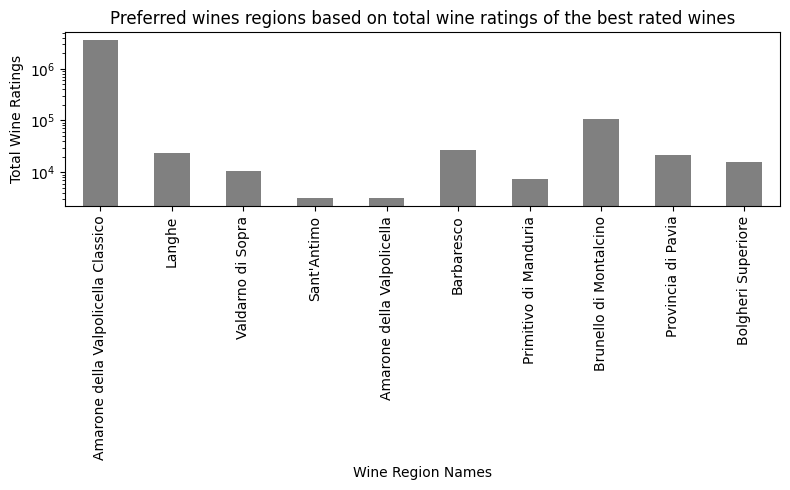

In [24]:
top10_1 = wines_preferred_bycustomers1.head(10)
plt.figure(figsize=(8, 5))
top10_1['total_ratings'].plot(kind= 'bar', color= 'grey')
plt.title('Preferred wines regions based on total wine ratings of the best rated wines')
plt.xlabel('Wine Region Names')
plt.ylabel('Total Wine Ratings')
plt.xticks(rotation= 90)
plt.yscale('log')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/Final Assignment/plot1.png")
plt.show()

Which wines (producers/regions) provide the best value for money (i.e., high ratings at relatively lower prices)?

In [25]:
preferred_wines = alldata_df[(alldata_df['rating_count']>= 500)]
best_value_wines = preferred_wines.sort_values(by = ['value_for_money'], ascending = False)[['name', 'region', 'rating', 'rating_count', 'price', 'value_for_money']]
best_value_wines.head(10)

,name,region,rating,rating_count,price,value_for_money
755,Stella Rosa Moscato d'Asti Semi-Sweet,Piemonte,4.2,5613,8.97,0.47
127,Roscato Rosso Dolce – Sweet Red,Provincia di Pavia,4.2,17332,9.97,0.42
692,Cupcake Moscato d'Asti,Moscato d'Asti,4.1,5960,10.99,0.37
905,Feudi del Duca Montepulciano d'Abruzzo 2023,Montepulciano d'Abruzzo,3.7,4936,9.99,0.37
837,Vigneti del Sole Montepulciano d'Abruzzo 2024,Montepulciano d'Abruzzo,3.8,5187,10.49,0.36
1675,Maschio Prosecco Brut,Prosecco,3.6,3298,9.99,0.36
608,Risata Moscato d'Asti,Moscato d'Asti,4.2,6583,11.98,0.35
823,Cavicchioli Lambrusco dell'Emilia Dolce Rosso,Emilia,3.9,5231,11.06,0.35
12952,Tavernello Rubicone Sangiovese 2024,Rubicone,3.3,2922,9.83,0.34
3232,Tavernello Rubicone Sangiovese 2024,Rubicone,3.3,2922,9.83,0.34


The reason why the following plot has 7 bars instead of 10, is because there's three region names that are repeated twice each: Moscato d'Asti, Montepulciano d'Abruzzo and Rubicone.

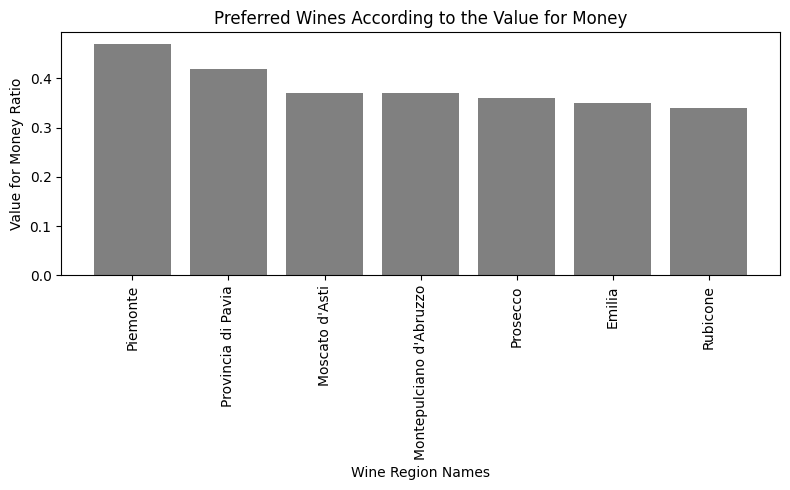

In [26]:
top10 = best_value_wines.head(10)
plt.figure(figsize=(8, 5))
plt.bar(top10['region'], top10['value_for_money'], color = 'grey')
plt.title('Preferred Wines According to the Value for Money')
plt.xlabel('Wine Region Names')
plt.ylabel('Value for Money Ratio')
plt.xticks(rotation= 90)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/Final Assignment/plotVM.png")
plt.show()

Based on your insights, what recommendations would you make to Slurpini.

My recommendation for Slurpini would be: I would show them the top 10 wines of each category. Each category could target different audiences. It not wise to assume everybody would want budget wine. There is a large audience that would value higher and premium quality. My analysis is based on the feedback of a lot of people. Slurpini could choose any region they want out of the three top 10 presented data frames. These top 10 data frames could be used throughout an entire year for making decisions about which producer they would like to collaborate with.